In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score



C:\Users\TANUSHREE\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
X,y=datasets.make_blobs(n_samples=100,centers=2,random_state=42)

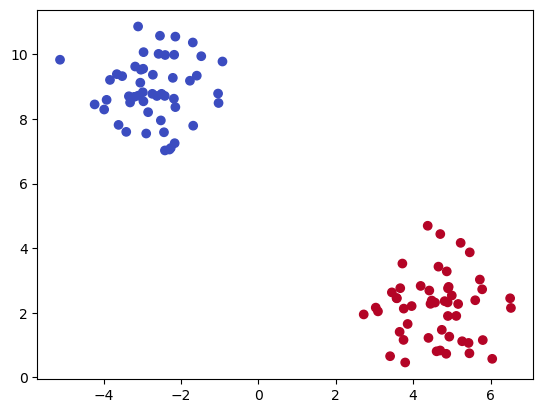

In [11]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm')

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
model=SVC(kernel='linear')
model.fit(X_train,y_train)

SVC(kernel='linear')

In [16]:
y_pred=model.predict(X_test)

In [17]:
print("Accuracy",accuracy_score(y_test,y_pred))

Accuracy 1.0


In [18]:
#first get min and max values of all features and also sholud not cut edges
x_min,x_max=X[:,0].min()-1,X[:,0].max()+1#feature 1 ka min max -1 +1 used to cut the edges
y_min,y_max=X[:,1].min()-1,X[:,1].max()+1#feature 2 ka min max


In [31]:
xx,yy=np.meshgrid(
    np.linspace(x_min,x_max,100),
    np.linspace(y_min,y_max,100)
)

In [32]:
# Step 2: Convert grid → list of points

In [33]:
grid = np.c_[xx.ravel(), yy.ravel()]

In [34]:
Z = model.predict(grid)

In [35]:
Z = Z.reshape(xx.shape)

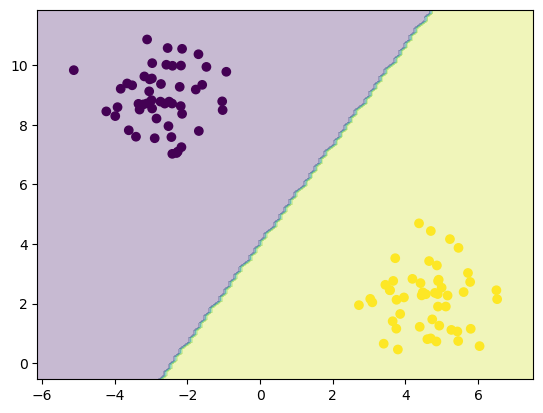

In [38]:
plt.contourf(xx, yy, Z, alpha=0.3) 
plt.scatter(X[:, 0], X[:, 1], c=y)   # actual data points
plt.show()

In [40]:
from sklearn.datasets import load_breast_cancer

In [41]:
data = load_breast_cancer()
X = data.data        # 30 features
y = data.target      # 0 or 1

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train SVM
model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

In [43]:
# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9824561403508771


In [50]:
#to plot these many features first we need to do pca and reduce features to 2


In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2)

In [48]:
from sklearn.svm import SVC

model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

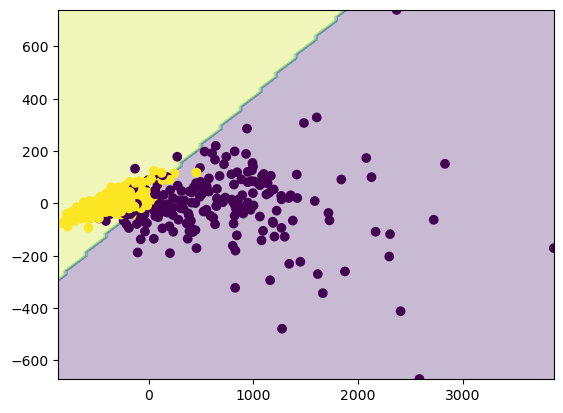

In [49]:

# Define range
x_min, x_max = X_pca[:, 0].min()-1, X_pca[:, 0].max()+1
y_min, y_max = X_pca[:, 1].min()-1, X_pca[:, 1].max()+1

# Meshgrid
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

# Predict
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid)
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)

In [51]:
# 🔹 Best Practice (Pipeline 🔥)

# Instead of doing manually, you can combine them:

# from sklearn.pipeline import Pipeline
# from sklearn.decomposition import PCA
# from sklearn.svm import SVC

# pipeline = Pipeline([
#     ('pca', PCA(n_components=2)),
#     ('svm', SVC(kernel='linear'))
# ])

# pipeline.fit(X, y)

In [52]:

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [53]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

In [54]:
for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"{k} kernel accuracy: {acc}")

linear kernel accuracy: 0.956140350877193
rbf kernel accuracy: 0.9473684210526315
poly kernel accuracy: 0.9473684210526315
sigmoid kernel accuracy: 0.4649122807017544


In [56]:
# kernel = 'linear' | 'rbf' | 'poly' | 'sigmoid'

In [57]:
# # C = 1.0
# rade-off 
# between margin and misclassification

# Small C → wider margin, more mistakes allowed
# Large C → tries to classify everything correctly
# Intuition:

 # gamma (for RBF, Poly, Sigmoid)
# gamma = 'scale' or value (e.g., 0.1)

# Small gamma → smooth boundary
# Large gamma → very complex boundary

# degree (only for polynomial)
# degree = 3

In [58]:
#hyper parameter tunning using grid search cv
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [59]:
#dictionar of parameters to be tunned
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.1, 0.01]
}

In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

In [62]:
# make object that contains all parameters and model type
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

In [63]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 0.01],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [64]:
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Score: 0.9758241758241759
